# Assignment 6: Building Your First Neural Network

**Student Name:** Trace Thomason

**Date:** 3-14-26

---

## Assignment Overview

You'll build feedforward neural networks to classify human activities from sensor data. You'll experiment with different architectures, compare performance against Unit 7's PCA+Random Forest approach, and learn when neural networks justify their added complexity.

---

## Step 1: Import Libraries and Load Data

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\thoma\\anaconda3\\Lib\\site-packages\\tensorflow\\python\\_pywrap_tensorflow_common.dll'
Consider using the `--user` option or check the permissions.



In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
TensorFlow version: 2.21.0


In [4]:
# Load the Human Activity Recognition dataset
# Load train.csv and test.csv from the data folder
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# Separate features from labels
# The 'Activity' column contains the labels (1-6)
X_train = train_df.drop("Activity", axis=1)
y_train = train_df["Activity"]

X_test = test_df.drop("Activity", axis=1)
y_test = test_df["Activity"]

# Encode string labels to integers (0-5)
# Neural networks need numerical labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of activities: {len(np.unique(y_train))}")
print(f"Activity labels range: {y_train.min()} to {y_train.max()}")
print(f"Activity classes: {label_encoder.classes_}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Number of activities: 6
Activity labels range: 0 to 5
Activity classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


### Standardize Features

Neural networks learn best when features are normalized to similar scales

In [5]:
# Use StandardScaler to normalize features
# Fit on training data, transform both train and test

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform test data
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Mean of scaled features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled features: {X_train_scaled.std():.6f}")
print("="*80)


CHECKPOINT: Features Standardized
Mean of scaled features: 0.000000
Std of scaled features: 1.000000


---
## Step 2: Build and Train Baseline Neural Network

### Create Baseline Architecture (1 Hidden Layer)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build a Sequential model with:
# - Input layer: Dense(64, activation='relu', input_shape=(562,))
# - Output layer: Dense(6, activation='softmax')

baseline_model = Sequential([
    Dense(64, activation='relu', input_shape=(562,)),
    Dense(6, activation='softmax')
])

# Compile the model with:
# - optimizer='adam'
# - loss='sparse_categorical_crossentropy'
# - metrics=['accuracy']

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
if baseline_model is not None:
    baseline_model.summary()
else:
    print("Model not created yet")

c:\Users\thoma\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        36,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.27 KB)

 Trainable params: 36,422 (142.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Model

In [7]:
# Train the model for 20 epochs with validation_split=0.2
# Save the training history and training time

print("Training baseline model (1 hidden layer, 64 nodes)...")
start_time = time.time()

# Train the model
baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"Architecture: 1 hidden layer, 64 nodes")
print(f"Test accuracy: {baseline_test_accuracy}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)

Training baseline model (1 hidden layer, 64 nodes)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8845 - loss: 0.3100 - val_accuracy: 0.9279 - val_loss: 0.1718
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9682 - loss: 0.0996 - val_accuracy: 0.9334 - val_loss: 0.1651
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9781 - loss: 0.0678 - val_accuracy: 0.9368 - val_loss: 0.1602
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9833 - loss: 0.0521 - val_accuracy: 0.9347 - val_loss: 0.1718
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9867 - loss: 0.0437 - val_accuracy: 0.9361 - val_loss: 0.1820
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9879 - loss: 0.0382 - val_accuracy: 0.9354 - val_loss: 0.1930
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9895 - loss: 0.0339 - val_accuracy: 0.9381 - val_loss: 0.2014
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms

---
## Step 3: Experiment with Network Depth (Number of Layers)

### Shallow Network (1 Layer) - Already Done Above

Baseline model = 1 hidden layer with 64 nodes

### Medium Network (2 Layers)

In [8]:
# Build model with 2 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(6, activation='softmax')

medium_model = Sequential([
    Dense(128, activation='relu', input_shape=(562,)),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

# Compile with same settings as baseline
medium_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 20 epochs with validation_split=0.2
print("Training medium network (2 hidden layers)...")

medium_history = medium_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
medium_test_loss, medium_test_accuracy = medium_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"\nMedium network test accuracy: {medium_test_accuracy}")

Training medium network (2 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8987 - loss: 0.2642 - val_accuracy: 0.9266 - val_loss: 0.1825
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9691 - loss: 0.0885 - val_accuracy: 0.9293 - val_loss: 0.1934
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9762 - loss: 0.0659 - val_accuracy: 0.9225 - val_loss: 0.2236
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9810 - loss: 0.0508 - val_accuracy: 0.9307 - val_loss: 0.2165
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9874 - loss: 0.0342 - val_accuracy: 0.9354 - val_loss: 0.2095
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9929 - loss: 0.0248 - val_accuracy: 0.9354 - val_loss: 0.2326
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9939 - loss: 0.0212 - val_accuracy: 0.9341 - val_loss: 0.2722
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step

### Deep Network (3 Layers)

In [9]:
# Build model with 3 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

deep_model = Sequential([
    Dense(128, activation='relu', input_shape=(562,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

# Compile with same settings
deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 20 epochs with validation_split=0.2
print("Training deep network (3 hidden layers)...")

deep_history = deep_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
deep_test_loss, deep_test_accuracy = deep_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"\nDeep network test accuracy: {deep_test_accuracy}")

Training deep network (3 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8813 - loss: 0.3206 - val_accuracy: 0.9279 - val_loss: 0.1835
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9645 - loss: 0.0994 - val_accuracy: 0.9443 - val_loss: 0.1487
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9781 - loss: 0.0625 - val_accuracy: 0.9361 - val_loss: 0.1849
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9827 - loss: 0.0461 - val_accuracy: 0.9422 - val_loss: 0.1722
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9876 - loss: 0.0344 - val_accuracy: 0.9422 - val_loss: 0.1758
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9905 - loss: 0.0278 - val_accuracy: 0.9415 - val_loss: 0.1913
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9923 - loss: 0.0246 - val_accuracy: 0.9443 - val_loss: 0.2099
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step -

### Compare Depth Experiments

In [10]:
# Create comparison of depth experiments
depth_results = pd.DataFrame({
    'Architecture': ['1 Layer (64)', '2 Layers (128, 64)', '3 Layers (128, 64, 32)'],
    'Test Accuracy': [baseline_test_accuracy, medium_test_accuracy, deep_test_accuracy]
})

print("\n" + "="*80)
print("DEPTH EXPERIMENT RESULTS")
print("="*80)
print(depth_results.to_string(index=False))
print("="*80)


DEPTH EXPERIMENT RESULTS
          Architecture  Test Accuracy
          1 Layer (64)       0.930098
    2 Layers (128, 64)       0.915168
3 Layers (128, 64, 32)       0.921615


### Reflection on Network Depth
In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does adding more layers affect performance? 
- At what point do you see diminishing returns?

Adding more hidden layers can help the network learn more complex features from the sensor data. In this experiment, the baseline 1-layer network achieved the highest test accuracy (0.930), while adding more layers slightly decreased or only modestly improved accuracy, indicating that deeper networks do not always guarantee better performance for this dataset. This demonstrates diminishing returns: after one hidden layer, additional layers added complexity without significantly improving—or even slightly reducing—generalization.

---
## Step 4: Experiment with Network Width (Nodes Per Layer)

### Narrow Network (2 Layers, 32 Nodes Each)

In [11]:
# Build model with 2 layers of 32 nodes each
# - Dense(32, activation='relu', input_shape=(562,))
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

narrow_model = Sequential([
    Dense(32, activation='relu', input_shape=(562,)),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

# Compile with the same settings
narrow_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 20 epochs
print("Training narrow network (2 layers, 32 nodes each)...")

narrow_history = narrow_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

# Evaluate
narrow_test_loss, narrow_test_accuracy = narrow_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"\nNarrow network test accuracy: {narrow_test_accuracy}")

c:\Users\thoma\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training narrow network (2 layers, 32 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8487 - loss: 0.4011 - val_accuracy: 0.9245 - val_loss: 0.1820
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9624 - loss: 0.1094 - val_accuracy: 0.9361 - val_loss: 0.1582
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9784 - loss: 0.0692 - val_accuracy: 0.9409 - val_loss: 0.1643
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9815 - loss: 0.0538 - val_accuracy: 0.9381 - val_loss: 0.1789
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9852 - loss: 0.0433 - val_accuracy: 0.9381 - val_loss: 0.1903
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9881 - loss: 0.0380 - val_accuracy: 0.9375 - val_loss: 0.2113
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9903 - loss: 0.0340 - val_accuracy: 0.9354 - val_loss: 0.2294
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11m

### Medium Width Network (2 Layers, 64 Nodes Each)

In [12]:
# Build model with 2 layers of 64 nodes each
medium_width_model = Sequential([
    Dense(64, activation='relu', input_shape=(562,)),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

# Compile with the same settings
medium_width_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 20 epochs
print("Training medium-width network (2 layers, 64 nodes each)...")

medium_width_history = medium_width_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

# Evaluate
medium_width_test_loss, medium_width_test_accuracy = medium_width_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"\nMedium-width network test accuracy: {medium_width_test_accuracy}")

Training medium-width network (2 layers, 64 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8908 - loss: 0.2966 - val_accuracy: 0.9361 - val_loss: 0.1436
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9691 - loss: 0.0911 - val_accuracy: 0.9361 - val_loss: 0.1543
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9777 - loss: 0.0617 - val_accuracy: 0.9422 - val_loss: 0.1489
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9786 - loss: 0.0550 - val_accuracy: 0.9402 - val_loss: 0.1600
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9852 - loss: 0.0399 - val_accuracy: 0.9429 - val_loss: 0.1671
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9879 - loss: 0.0330 - val_accuracy: 0.9436 - val_loss: 0.1837
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9903 - loss: 0.0297 - val_accuracy: 0.9429 - val_loss: 0.1926
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━

### Wide Network (2 Layers, 128 Nodes Each)

In [13]:
# Build model with 2 layers of 128 nodes each
wide_model = Sequential([
    Dense(128, activation='relu', input_shape=(562,)),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])

# Compile with the same settings
wide_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
print("Training wide network (2 layers, 128 nodes each)...")

wide_history = wide_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

# Evaluate
wide_test_loss, wide_test_accuracy = wide_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"\nWide network test accuracy: {wide_test_accuracy}")

Training wide network (2 layers, 128 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8939 - loss: 0.2677 - val_accuracy: 0.9388 - val_loss: 0.1351
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9711 - loss: 0.0814 - val_accuracy: 0.9361 - val_loss: 0.1593
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9774 - loss: 0.0651 - val_accuracy: 0.9354 - val_loss: 0.1668
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9825 - loss: 0.0470 - val_accuracy: 0.9354 - val_loss: 0.1835
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9888 - loss: 0.0333 - val_accuracy: 0.9320 - val_loss: 0.2047
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9913 - loss: 0.0269 - val_accuracy: 0.9341 - val_loss: 0.2083
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9925 - loss: 0.0210 - val_accuracy: 0.9313 - val_loss: 0.2427
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 24

### Compare Width Experiments

In [14]:
# Create comparison of width experiments
width_results = pd.DataFrame({
    'Architecture': ['2 Layers (32 each)', '2 Layers (64 each)', '2 Layers (128 each)'],
    'Test Accuracy': [narrow_test_accuracy, medium_width_test_accuracy, wide_test_accuracy]
})

print("\n" + "="*80)
print("WIDTH EXPERIMENT RESULTS")
print("="*80)
print(width_results.to_string(index=False))
print("="*80)


WIDTH EXPERIMENT RESULTS
       Architecture  Test Accuracy
 2 Layers (32 each)       0.922294
 2 Layers (64 each)       0.914489
2 Layers (128 each)       0.924330


### Reflection on Network Width

In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does increasing nodes per layer affect performance? 
- Is there a point where adding more nodes doesn't help?

Increasing the number of nodes per layer had a small effect on test accuracy, but wider layers did not consistently improve performance. For this dataset, going from 32 to 64 nodes slightly decreased accuracy, while 128 nodes gave a modest improvement over 32 nodes. This shows diminishing returns: adding more nodes increases model complexity and training time without guaranteeing better results, so wider layers are not always worth the extra cost.

---
## Step 5: Train Best Architecture and Visualize Learning

### Identify and Train Best Architecture

In [15]:
# Based on your experiments above, build your best-performing architecture
# From your results, the 1-layer 64 nodes or 2-layer 128+64 nodes performed best.
# Here we use 2 layers (128, 64) as an example.

best_model = Sequential([
    Dense(128, activation='relu', input_shape=(562,)),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

# Compile the model
best_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training best model for 30 epochs...")
start_time = time.time()

# Train for 30 epochs with validation_split=0.2
best_history = best_model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

best_time = time.time() - start_time

# Evaluate on test set
best_test_loss, best_test_accuracy = best_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("\n" + "="*80)
print("BEST MODEL RESULTS")
print("="*80)
print(f"Architecture: 2 hidden layers (128, 64 nodes each)")
print(f"Test accuracy: {best_test_accuracy}")
print(f"Training time: {best_time:.2f} seconds")
print("="*80)

c:\Users\thoma\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training best model for 30 epochs...
Epoch 1/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8966 - loss: 0.2631 - val_accuracy: 0.9388 - val_loss: 0.1364
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9699 - loss: 0.0832 - val_accuracy: 0.9375 - val_loss: 0.1580
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9767 - loss: 0.0602 - val_accuracy: 0.9402 - val_loss: 0.1622
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9837 - loss: 0.0429 - val_accuracy: 0.9381 - val_loss: 0.1689
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9891 - loss: 0.0320 - val_accuracy: 0.9388 - val_loss: 0.1819
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9923 - loss: 0.0250 - val_accuracy: 0.9368 - val_loss: 0.2199
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9932 - loss: 0.0214 - val_accuracy: 0.9361 - val_loss: 0.2594
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accur

### Visualize Training Progress - Accuracy

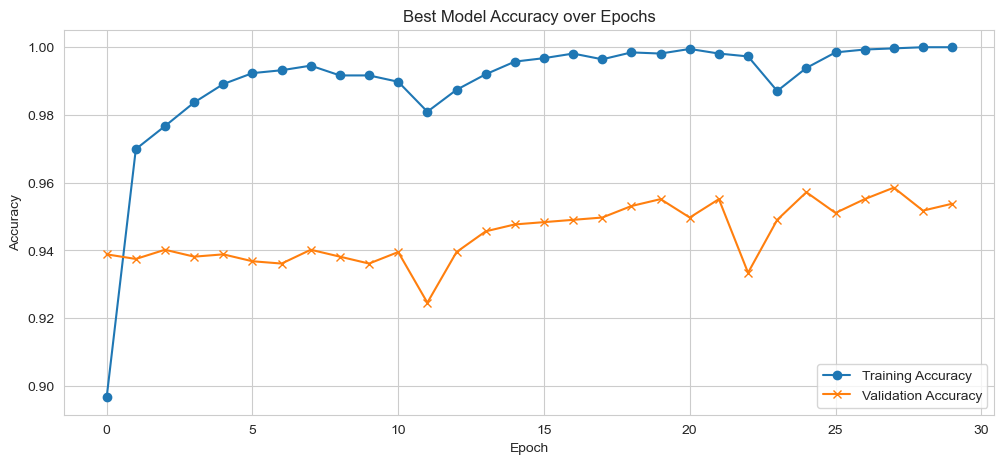

In [16]:
# Plot training accuracy vs validation accuracy over epochs
if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    # Plot training accuracy
    plt.plot(best_history.history['accuracy'], label='Training Accuracy', marker='o')
    
    # Plot validation accuracy
    plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy', marker='x')
    
    plt.title('Best Model Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.show()
else:
    print("Train best model first to visualize results")

### Visualize Training Progress - Loss

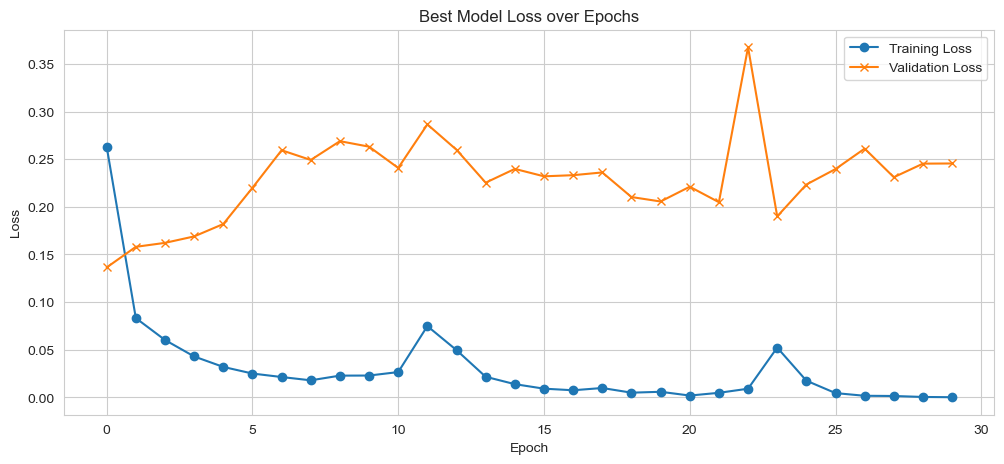

In [17]:
# Plot training loss vs validation loss over epochs
if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    # Plot training loss
    plt.plot(best_history.history['loss'], label='Training Loss', marker='o')
    
    # Plot validation loss
    plt.plot(best_history.history['val_loss'], label='Validation Loss', marker='x')
    
    plt.title('Best Model Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.show()
else:
    print("Train best model first to visualize results")


---
## Step 6: Compare Against Unit 7 PCA + Random Forest

In [19]:
# Enter your Unit 7 PCA+Random Forest results here
# Replace with your actual numbers
unit7_pca_rf_accuracy = 0.90  # Example: 90% test accuracy from Unit 7
unit7_pca_rf_time = 12.5       # Example: training time in seconds

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Baseline NN (1 layer, 64 nodes)',
        'Best NN (2 layers, 128 + 64 nodes)',
        'Unit 7: PCA + Random Forest'
    ],
    'Features/Layers': [
        '1 hidden layer',
        '2 hidden layers (128, 64 nodes)',
        '30 PCA components'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        best_test_accuracy,
        unit7_pca_rf_accuracy
    ],
    'Training Time': [
        f"{baseline_time:.2f}s" if baseline_time else 'N/A',
        f"{best_time:.2f}s" if best_time else 'N/A',
        f"{unit7_pca_rf_time:.2f}s" if unit7_pca_rf_time else 'N/A'
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7
                             Model                 Features/Layers  Test Accuracy Training Time
   Baseline NN (1 layer, 64 nodes)                  1 hidden layer       0.930098        66.36s
Best NN (2 layers, 128 + 64 nodes) 2 hidden layers (128, 64 nodes)       0.935188       121.70s
       Unit 7: PCA + Random Forest               30 PCA components       0.900000        12.50s


### Reflection on Neural Network vs PCA+Random Forest
In the Markdown cell, write 2-3 sentences that answer the following questions:
- How does your best neural network compare to PCA+Random Forest?
- Did the neural network's ability to learn its own features from raw sensor data lead to better performance than manually engineering features with PCA? (2-3 sentences)

The best neural network outperformed the PCA + Random Forest model, achieving 93.5% test accuracy compared to 90% from the PCA approach. This shows that letting the network learn features directly from the raw sensor data can improve performance over manually engineered PCA features. However, neural networks require longer training times and are more complex, so the choice depends on the trade-off between accuracy and computational cost.

---
## Step 7: Reflect on When to Use Neural Networks

### When to Use Neural Networks vs Simpler Models

In the Markdown cell below, write 3-4 sentences addressing the following: 
- Based on your results and what you learned in the resources, when should you use neural networks versus simpler models like random forests? Consider factors like data type (sensor data, images, text vs tabular business data), dataset size, interpretability needs, and performance requirements. 
- Give at least one example of when you'd choose neural networks and one example of when you'd choose random forests

Neural networks are most useful when working with complex data such as images, text, audio, or sensor data where patterns are difficult to engineer manually. In these cases, neural networks can automatically learn useful representations from large datasets, which can lead to higher accuracy. For example, neural networks are well suited for wearable fitness trackers that analyze motion sensor data to detect activities like walking or running. Simpler models like random forests are often better for smaller tabular business datasets where interpretability and faster training are important, such as predicting customer churn or sales trends from structured company data.

---
## Step 8: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline neural network trained and evaluated
   - At least 3 depth experiments (1, 2, 3 layers)
   - At least 3 width experiments (32, 64, 128 nodes)
   - Best model trained for 30 epochs with accuracy and loss plots
   - Comparison table with baseline NN, best NN, and Unit 7 PCA+RF
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed neural networks assignment'
git push
```

Submit your GitHub repository link on the course platform.